# Construct quadratic program

In [1]:
import json
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.optimize import minimize
from pathlib import Path
from tqdm import tqdm

from qiskit import QuantumCircuit
from qiskit.primitives import (
    BackendSampler,
    BackendSamplerV2,
    BackendEstimator,
    BackendEstimatorV2,
    StatevectorEstimator,
    Estimator,
)
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit_optimization.applications import Maxcut
from qiskit_optimization.algorithms import MinimumEigenOptimizer, GurobiOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import NELDER_MEAD, COBYLA, L_BFGS_B
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.primitives import (
    Sampler as AerSampler,
    SamplerV2 as AerSamplerV2,
    Estimator as AerEstimator,
    EstimatorV2 as AerEstimatorV2,
)

from lcc import FullVQE, LCCVQE
from lcc.knapsack import Knapsack

TWO_PI = 2 * np.pi

sc140_data_dir = Path('data/140')


class CustomVQE(FullVQE):
    @staticmethod
    def generate_full_ansatz(num_qubits: int, reps: int = 1) -> QuantumCircuit:
        qc = QuantumCircuit(num_qubits)
        theta = ParameterVector('θ', num_qubits)
        
        for i in range(num_qubits):
            qc.rx(theta[i], i)

        return qc
    
    @staticmethod
    def generate_local_ansatz(num_qubits: int) -> QuantumCircuit:
        qc = QuantumCircuit(num_qubits)
        theta = ParameterVector('θ', 2 * num_qubits)

        # First layer RY
        for k in range(num_qubits):
            qc.ry(theta[k], k)

        # Entangling CNOT
        for k in range(num_qubits - 1):
            qc.cz(k, k + 1)

        # Second layer RY
        for k in range(num_qubits):
            qc.ry(theta[num_qubits + k], k)

        return qc


## Generate Max-cut instances

In [60]:
n = 10
G = nx.random_regular_graph(2, n, seed=0)
max_cut = Maxcut(G)
qp = max_cut.to_quadratic_program()
# print(qp.prettyprint())

## Load Knapsack instances

In [10]:
file_path = Path('data/90/data_3.json')
knapsack = Knapsack(file_path)
qp = knapsack.quadratic_program
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)

## Load Supply Chain instances

In [16]:
from lcc.supply_chain import construct_qiskit_quadratic_program

file_path = sc140_data_dir/'data_0.json'
with file_path.open() as f:
    params = json.load(f)

qp = construct_qiskit_quadratic_program(params)
# print(qp.prettyprint())

## Exact solution

In [7]:
exact_solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())
exact_result = exact_solver.solve(qp)
true_obj = exact_result.fval
print(exact_result.prettyprint())

objective function value: 25.0
variable values: x_0_0=0.0, x_0_1=0.0, x_0_2=1.0, x_1_0=0.0, x_1_1=1.0, x_1_2=0.0, x_2_0=0.0, x_2_1=0.0, x_2_2=1.0, x_3_0=1.0, x_3_1=0.0, x_3_2=0.0
status: SUCCESS


In [ ]:
gurobi_result = GurobiOptimizer().solve(qp)
true_obj = gurobi_result.fval
print('Gurobi cost:', true_obj)

Gurobi cost: 15.0


# Solve using LCC

In [ ]:
estimator = StatevectorEstimator()
# estimator = None
optimizer = L_BFGS_B()

solver = LCCVQE(
    qp,
    estimator=estimator,
    optimizer=optimizer,
)

initial_params = solver.generate_random_params()
print('Initial params:', initial_params.view())
solver.compute_energy(initial_params)

In [20]:
estimator = StatevectorEstimator()
# estimator = None
optimizer = L_BFGS_B()

n_trials = 1
shots = int(1e5)
costs = []
solutions = []
feasibles = []

for _ in tqdm(range(n_trials)):
    solver = LCCVQE(
        qp,
        shots=shots,
        estimator=estimator,
        optimizer=optimizer,
    )

    result = solver.solve(initial_point=None, run_sampler=False)
    expectation = -(result.fun + solver.offset)
    # feasible = qp.is_feasible(solver.optimal_solution)

    costs.append(expectation)
    # solutions.append(solver.optimal_solution)
    # feasibles.append(feasible)

    print('Expectation:', expectation)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [6:21:06<00:00, 22866.73s/it]

Expectation: -59616.45415434986


## HEA

In [9]:
backend = AerSimulator(method='matrix_product_state')
estimator = BackendEstimatorV2(backend=backend)
optimizer = COBYLA()

n_trials = 1
shots = int(1e4)
costs = []
solutions = []
feasibles = []
count = 0

while True:
    count += 1
    solver = FullVQE(
        qp,
        shots=shots,
        estimator=estimator,
        optimizer=optimizer,
    )

    result = solver.solve(initial_point=None)
    expectation = -(result.fun + solver.offset)
    # feasible = qp.is_feasible(solver.optimal_solution)

    if np.isclose(expectation, true_obj, atol=1e-3):
        break

print('No. trials:', count)
print('Expectation:', expectation)
    # print('Feasibility:', feasible)

    # costs.append(expectation)
    # solutions.append(solver.optimal_solution)
    # feasibles.append(feasible)

No. trials: 17
Expectation: 24.999999999312422


## All-Rx

In [ ]:
backend = AerSimulator(method='matrix_product_state')
estimator = BackendEstimatorV2(backend=backend)
optimizer = COBYLA()

n_trials = 1
shots = int(1e4)
costs = []
solutions = []
feasibles = []
count = 0

while True:
    count += 1
    solver = CustomVQE(
        qp,
        shots=shots,
        estimator=estimator,
        optimizer=optimizer,
    )

    initial_point = solver.generate_random_params(scale=np.pi)
    result = solver.solve(initial_point=initial_point)
    expectation = -(result.fun + solver.offset)
    # feasible = qp.is_feasible(solver.optimal_solution)

    if np.isclose(expectation, true_obj, atol=1e-3):
        break

print('No. trials:', count)
print('Expectation:', expectation)

## Plot landscape

In [166]:
def index_roller(num_params):
    return np.random.randint(0, num_params, size=(2,))

index_roller(len(result.x))

array([  5, 189])

In [ ]:
def make_param_vec(t1m_flat, t2m_flat, full_params, t1_idx=0, t2_idx=1):
    fp = full_params.copy()
    for t1, t2 in zip(t1m_flat, t2m_flat):        
        fp[t1_idx] = t1
        fp[t2_idx] = t2

        yield fp

idx1 = 20
idx2 = 26
theta_1 = np.linspace(0, TWO_PI, 100)
theta_2 = np.linspace(0, TWO_PI, 100)
t1m, t2m = np.meshgrid(theta_1, theta_2)
t1m_flat = t1m.reshape(-1)
t2m_flat = t2m.reshape(-1)

opt_params = [
    3.23291829e+00, 3.13610718e+00, 5.04368451e+00, 2.25867096e-02,
    1.15053656e-02, 3.22471186e+00, 3.13189692e+00, 6.34190795e+00,
    1.01803023e-02, 6.11367264e+00, 6.28515784e+00, 4.99573591e+00,
    3.13083777e+00,-2.12867988e-01,-3.47365394e-02, 3.09324354e+00,
    7.07945334e+00, 6.29767154e+00, 3.17994317e+00, 5.40901552e-01,
    6.25205928e+00,-1.23298599e-01, 3.13878381e+00, 1.16395723e+00,
    7.86852594e-01, 3.15199500e+00, 5.06792141e+00, 4.07164666e+00,
    3.30239094e+00, 1.35842061e+00,-2.20188234e-02, 6.49773032e+00,
    4.93790807e+00,-6.44189131e-02, 1.41459606e+00,-2.29381049e-03,
    2.10663515e+00, 2.94501917e+00, 6.37897684e-02,-1.27118481e-02,
    4.41114380e+00, 3.14281486e+00, 2.97297454e+00, 5.20980582e+00,
    1.67696012e+00, 6.03332842e+00, 4.94872106e+00, 5.83749849e+00,
    4.50412849e+00, 5.89503574e+00, 1.58627591e-01, 4.43904179e+00,
    -1.59229596e-01, 3.73827262e+00, 6.04977675e+00,-2.89059473e-01,
    2.92622094e+00, 3.01769266e+00, 3.02299970e+00, 3.35123385e+00,
    3.25677276e+00, 4.77028242e+00, 4.49981098e+00, 6.27292001e+00,
    3.12135978e+00, 1.42993297e+00, 2.92792436e+00, 5.28790086e+00,
    6.40655466e+00,-9.23749604e-03, 4.52004368e+00, 6.28310936e+00,
    -2.29226492e-03, 4.58895043e+00, 3.14099727e+00,-1.39681498e-02,
    3.13167489e+00, 6.93368884e+00, 6.28765893e+00, 4.19517066e+00,
    3.14226122e+00,-7.33196570e-04, 6.16392017e+00, 3.05349995e+00,
    -1.37048800e-02, 1.25638946e+00, 3.14203115e+00, 3.13481661e+00,
    5.73708944e+00, 3.14660462e+00, 6.23261517e+00, 5.38213997e+00,
    3.11814051e+00, 1.29290402e-02, 3.00665471e+00, 3.32970968e+00,
    4.63100394e-01, 6.31846256e+00, 3.14558310e+00, 6.18654068e+00,
    1.26854828e+00, 1.73249817e-02, 3.13457357e+00, 3.11371446e+00,
    5.70694709e+00, 2.19023037e-04, 3.04882233e+00, 6.27329728e+00,
    1.54727911e+00,-1.02250345e-02, 1.30361582e+00,-2.13230906e-05,
    2.24331359e+00, 6.28115646e+00, 6.27350338e+00, 4.24835411e+00,
    1.08014304e+00, 1.77257410e+00, 3.17512539e+00, 6.30197789e+00,
    7.16212104e-01, 4.45398992e+00,-5.88870897e-03, 4.42020630e+00,
    6.26165823e+00, 2.59567366e+00,-2.07037016e-01, 3.14244272e+00,
    4.18799965e+00, 6.04920371e+00, 3.37334181e+00, 3.28864881e+00,
    -5.70030165e-01, 9.60688424e-03, 8.64921861e-01, 3.14162462e+00,
    4.06405712e+00,-1.89921931e-02, 2.00410156e+00, 4.95406439e+00,
    1.27941657e-02, 2.34456103e+00, 3.14086661e+00, 3.03598811e-01,
    1.48490347e+00, 1.85146450e+00,-6.11970571e-03, 7.67726022e-01,
    9.36988710e-02, 3.05814814e+00, 5.04425883e+00, 3.15701695e+00,
    -1.26131729e-02, 3.21917732e+00, 3.12954421e+00, 3.18381722e+00,
    4.60378638e-03, 6.45301953e+00, 6.28920658e+00, 5.01484432e+00,
    3.14932032e+00,-2.05015646e-01, 3.10213401e+00, 6.27709795e+00,
    7.26974867e-01, 2.00371167e-02, 3.17484041e+00, 5.48272805e-01,
    6.31429766e+00, 6.15919171e+00, 3.14075448e+00, 7.77394036e-01,
    3.75531035e+00, 3.11980233e+00, 6.69876961e+00, 6.90469584e+00,
    -2.04260992e-02, 1.35464650e+00,-1.63506478e-02, 2.47121381e+00,
    1.25871138e+00, 2.70732442e+00, 2.12384307e+00,-7.80548146e-02,
    5.11663388e+00, 2.96632224e+00, 5.59914812e+00, 5.23277083e+00,
    4.42584304e+00, 5.02761932e+00, 5.97929009e+00, 3.71437996e+00,
    4.12658633e+00, 3.29117971e+00, 4.97828411e+00, 3.05816825e+00,
    1.81321386e+00, 6.16224369e+00, 2.65128128e+00, 5.73895992e+00,
    6.41632168e+00, 2.37111385e+00, 8.73868176e-01, 6.53867897e+00,
    2.45081376e+00, 3.27755607e+00, 3.05954348e+00, 2.86836771e+00,
    3.03093485e+00, 2.22957260e+00, 5.21786426e-01,-2.67397485e-02,
    2.74906702e+00, 8.29377869e-01, 2.31223307e+00, 5.39080394e+00,
    4.39777784e+00, 4.65755957e-01, 1.76724390e+00,-1.18036418e-03,
    6.26691170e+00, 4.58849640e+00, 3.14072882e+00, 6.30160416e+00,
    8.65977256e-02, 6.32279087e-01,-7.24891774e-04, 4.19484154e+00,
    3.15320616e+00, 6.28278779e+00, 3.02268537e+00, 3.23264415e+00,
    3.11018411e+00, 1.26266225e+00, 3.14058089e+00, 3.14244299e+00,
    6.35447260e-01, 3.10662786e+00, 6.25178112e+00, 2.26378718e+00,
    3.06613666e+00, 4.21827829e-03, 2.99509809e+00, 1.04780592e+00,
    3.70112967e+00, 6.32385555e+00, 3.13643324e+00, 5.86466660e+00,
    1.90905107e+00, 6.29236429e+00, 3.15123111e+00, 6.13234981e+00,
    5.71073654e+00,-2.38275584e-03, 3.23344159e+00,-8.53365243e-03,
    4.74265077e+00, 3.16803984e+00, 4.98332789e+00, 1.66781097e-02,
    4.02239036e+00, 4.37978826e-03, 6.27245654e+00, 4.55298288e+00,
    2.85720580e+00, 1.92466169e+00, 3.21569508e+00, 3.72476924e+00,
    3.26429483e+00, 1.85758535e+00, 1.71147784e-01, 1.86591357e+00,
    2.93991844e+00, 3.27177741e+00,-1.27548196e-01, 3.13855722e+00,
    4.16989886e+00, 3.15230613e+00, 2.20072539e-01, 1.67392809e+00,
    2.16613757e+00, 3.18748777e+00, 8.59350182e-01, 3.14970842e+00,
    4.06353490e+00, 3.99328503e+00, 7.28120719e-01, 5.80445689e+00,
    6.27891606e+00, 2.32277957e+00, 3.14256017e+00, 3.47062093e+00,
    3.47271813e+00, 4.65172941e+00,-3.22077022e-02, 7.55127800e-01
]
# opt_params = result.x

exp_iter = map(solver.compute_energy, make_param_vec(t1m_flat, t2m_flat, opt_params, idx1, idx2))
exp_arr = np.array(list(exp_iter)).reshape((100, 100)) + solver.offset

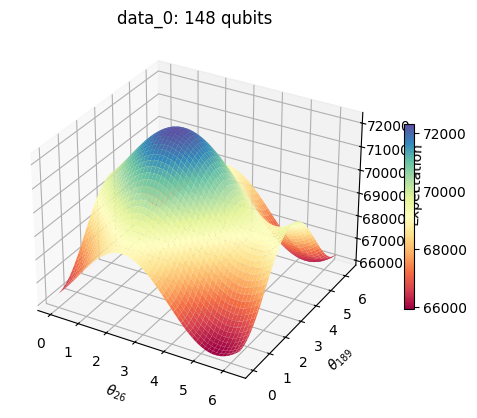

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
surf = ax.plot_surface(t1m, t2m, exp_arr, cmap='Spectral')

ax.set_xlabel(r"$\theta_{idx1}$".replace('idx1', str(idx1)))
ax.set_ylabel(r"$\theta_{idx2}$".replace('idx2', str(idx2)))
ax.set_zlabel("Expectation")
ax.set_title(f'{file_path.stem}: {solver.num_qubits} qubits')
fig.colorbar(surf, shrink=.5)

plt.show()

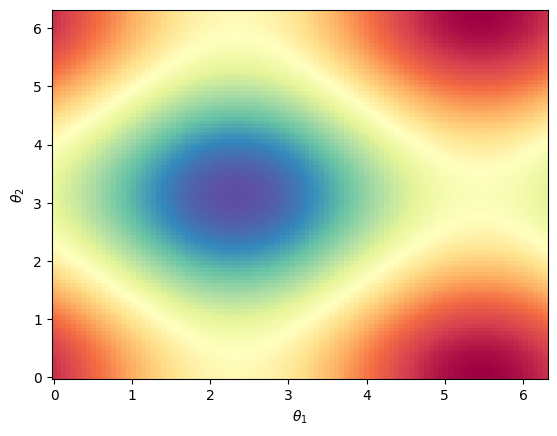

In [14]:
fig, ax = plt.subplots()
ax.pcolormesh(t1m, t2m, exp_arr, cmap='Spectral')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
plt.show()

In [22]:
def obj_func(params):
    return solver.compute_energy(params)

def compute_gradient(f, x, index, h=.001):
    x_plus = x.copy()
    x_plus[index] += h

    x_minus = x.copy()
    x_minus[index] -= h

    return (f(x_plus) - f(x_minus)) / (2 * h)

n_trials = 100
index = np.random.randint(0, 2 * solver.num_qubits)
gradients = []
print(f'Taking gradient w.r.t. param #{index}...')
for i in range(n_trials):
    params = solver.generate_random_params()
    gradient = compute_gradient(obj_func, params, index)
    gradients.append(gradient)
    print(f'Gradient {i}:', gradient)

print()
print('Gradient mean:', np.mean(gradients))
print('Gradient variance:', np.std(gradients)**2)

Taking gradient w.r.t. param #284...
Gradient 0: -3253649.181455956
Gradient 1: 2405593.453865731
Gradient 2: 2177445.798855275
Gradient 3: 1654589.8996787146
Gradient 4: 582434.9459374498
Gradient 5: -853666.6898280382
Gradient 6: 2128978.177715093
Gradient 7: -1626871.4483690565
Gradient 8: 1936095.1443464728
Gradient 9: 213660.36305390298
Gradient 10: -2394275.0261093024
Gradient 11: 1975203.5282440484
Gradient 12: 3802637.745172018
Gradient 13: -916713.8570658863
Gradient 14: -1009485.0504593924
Gradient 15: -1329637.5171748223
Gradient 16: -2992307.979594916
Gradient 17: 1838948.3094264288
Gradient 18: 2245934.6985416487
Gradient 19: -1053708.2251058891
Gradient 20: -1518514.6294600563
Gradient 21: -2622640.74002672
Gradient 22: -95680.62173592625
Gradient 23: -1047822.8691826225
Gradient 24: 2962196.1236076895
Gradient 25: 197960.00714646652
Gradient 26: -3349836.344063282
Gradient 27: -2374524.8096957803
Gradient 28: -1313188.928131014
Gradient 29: -2242598.252326483
Gradient 30

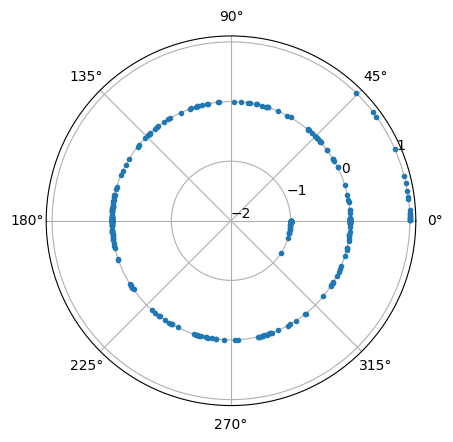

In [149]:
two_pi = 2 * np.pi
theta = result.x % two_pi
r = result.x // two_pi

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(theta, r, '.')
# ax.set_rmax(2)
ax.set_rticks([-2, -1, 0, 1])  # Less radial ticks
# ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
ax.grid(True)

# ax.set_title("A line plot on a polar axis", va='bottom')
plt.show()

In [ ]:
# def obj_func(params):
#     return solver.compute_energy(params)

# result = minimize(obj_func, initial_params, method='cobyla')
# result

In [ ]:
qp_solution = solver.get_qp_solution()
print('QP solution:', qp_solution)

QP solution: [0. 0. 0. 1. 0. 0. 0. 1. 0.]


In [ ]:
qp.objective.evaluate(qp_solution)

11.0

# Solve without LCC

In [ ]:
ansatz = TwoLocal(
    num_qubits=qubo.get_num_vars(),
    rotation_blocks='ry',
    entanglement_blocks='cz',
    entanglement='circular',
    reps=1,
)
result = estimator.run([(ansatz, solver.hamiltonian, initial_params)]).result()[0]
result.data.evs

In [ ]:
def obj_func(params):
    result = estimator.run([(ansatz, solver.hamiltonian, params)]).result()[0]
    return result.data.evs

initial_params = solver.generate_random_params()
result = minimize(obj_func, initial_params, method='l-bfgs-b')
print('Expectation:', -(result.fun + solver.offset))

# Reconstructing the quasi-prob distribution

## Brute force (run the full circuit)

In [ ]:
backend = AerSimulator(method='matrix_product_state')
sampler = BackendSampler(backend=backend)

num_qubits = qp.get_num_vars()
ansatz = TwoLocal(
    num_qubits=num_qubits,
    rotation_blocks='ry',
    entanglement_blocks='cz',
    entanglement='circular',
    reps=1,
)
ansatz.measure_all()

initial_params = np.random.rand(2 * num_qubits) * 2 * np.pi
result = sampler.run(ansatz, initial_params).result()

### Linear entanglement

In [2]:
backend = AerSimulator(method='matrix_product_state')
sampler = BackendSamplerV2(backend=backend)
# sampler = AerSamplerV2()

reps = 9
num_qubits = 100

qc = QuantumCircuit(num_qubits)
thetas = ParameterVector('theta', (reps + 1) * num_qubits)

# Initial rotation layer
for i in range(num_qubits):
    qc.ry(thetas[i], i)

for r in range(1, reps + 1):
    # Entangling layer
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)

    # Repeated rotation layer
    for i in range(num_qubits):
        qc.ry(thetas[r * num_qubits + i], i)

qc.measure_all()

initial_params = np.random.rand((reps + 1) * num_qubits) * 2 * np.pi

In [3]:
%%timeit -n1 -r1
result = sampler.run([(qc, initial_params)]).result()[0]

1min 2s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


### Full entanglement

In [7]:
backend = AerSimulator(method='matrix_product_state')
sampler = BackendSamplerV2(backend=backend)
# sampler = AerSamplerV2()

reps = 5
num_qubits = 100

qc = QuantumCircuit(num_qubits)
thetas = ParameterVector('theta', (reps + 1) * num_qubits)
for i in range(num_qubits):
    qc.ry(thetas[i], i)

for r in range(1, reps + 1):
    for i, j in combinations(range(num_qubits), 2):
        qc.cx(i, j)

    for i in range(num_qubits):
        qc.ry(thetas[r * num_qubits + i], i)

qc.measure_all()

initial_params = np.random.rand((reps + 1) * num_qubits) * 2 * np.pi

In [8]:
%%timeit -n1 -r1
result = sampler.run([(qc, initial_params)]).result()[0]

### Time taken for MPS (in seconds; reps = 1)

| # qubits | Linear ent. | Full ent.                   |
|----------|-------------|-----------------------------|
| 500      | 2.3         | 6.6                         |
| 1000     | 4.9         | 22.8                        |
| 5000     | 24.8        | (crashed)                   |
| 10000    | 42.3        | (crashed)      |

### Time taken for MPS (# qubits = 100)

| Reps | Linear ent. | Full ent. |
|------|-------------|-----------|
| 1    | 0.45        | 0.5       |
| 5    | 0.49        | > 30 mins |
| 7    | 3.3         | -         |
| 8    | 10.3        | -         |
| 9    | 62.7        | -         |
| 10   | 161         | -         |

Gave up on full entanglement.